# Drawing Biological Cascade Plots with ReCoN

This tutorial demonstrates how to represent a ReCoN molecular cascade as a **biological cell diagram**. Unlike a Sankey diagram, the cascade plot places ligands in the extracellular space and regulatory molecules inside their source or receiving cells.

You will learn how to:

1. Build and explore the same multicellular network used in the Sankey tutorial
2. Draw intracellular regulation in a focal cell type
3. Extend the view to extracellular ligands
4. Display the complete cascade, including regulation in source cells
5. Inspect the edges selected for each plot
6. Compare two matched ReCoN runs with a contrast cascade

**Use case**: Given a gene program in one cell type, visualize the connected receptors, transcription factors, ligands, and source-cell regulators predicted by ReCoN.

> This tutorial follows the [`2.2.Heart_Failure_cascade_plots.ipynb`](https://github.com/cantinilab/recon_reproducibility/blob/main/showcases_paper/Heart_Infarction_Fibrosis/2.2.Heart_Failure_cascade_plots.ipynb) workflow in the [`recon_reproducibility`](https://github.com/cantinilab/recon_reproducibility) repository.

## Setup

Tutorials 3 and 7 share the same input data and network construction. Download the required files if they are not already available:

In [1]:
from recon.data import fetch_tutorial_data

for filename in [
    "perturbation_tuto/rna.h5ad",
    "perturbation_tuto/grn.csv",
]:
    fetch_tutorial_data(filename, data_dir="./data")

File already exists: ./data/perturbation_tuto/rna.h5ad
File already exists: ./data/perturbation_tuto/grn.csv


/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/recon/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import liana as li

import recon
import recon.data
import recon.explore
from recon.plot import cascade_plot, contrast_cascade_plot

## 1. Create the multicellular network

A cascade plot does not infer a new network. It extracts connected paths from a `Multicell` model and its RWR results. We therefore reproduce the setup from the Sankey tutorial: a GRN for intracellular regulation, a LIANA network for cell-cell communication, and receptor-to-gene prior knowledge.

In [3]:
rna = sc.read_h5ad("./data/perturbation_tuto/rna.h5ad")

grn = pd.read_csv("./data/perturbation_tuto/grn.csv")
grn = grn.sort_values("weight", ascending=False).head(500_000)
grn["source"] = grn["source"].str.capitalize() + "_TF"
grn["target"] = grn["target"].str.capitalize()

li.method.cellphonedb(
    rna, resource_name="mouseconsensus", expr_prop=0.0, use_raw=False,
    groupby="celltype", verbose=True, key_added="cpdb_res",
)
ccc = rna.uns["cpdb_res"][[
    "ligand", "receptor", "lr_means", "source", "target"
]].rename(columns={
    "ligand": "source", "receptor": "target", "lr_means": "weight",
    "source": "celltype_source", "target": "celltype_target",
})
ccc = ccc[ccc["weight"] != 0].copy()

receptor_genes = recon.data.load_data.load_receptor_genes(
    "mouse_receptor_gene_from_NichenetPKN"
)
network_genes = set(grn["source"]) | set(grn["target"])
receptor_genes = receptor_genes[receptor_genes["target"].isin(network_genes)]

Using resource `mouseconsensus`.
Using `.X`!
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/recon/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
15364 features of mat are empty, they will be removed.
Make sure that normalized counts are passed!
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/recon/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/pasteur/appa/homes/rtrimbou/miniconda3/envs/snakemake/envs/recon/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.36 of entities in the resource are missing 

Generating ligand-receptor stats for 1296 samples and 937 features


100%|██████████| 1000/1000 [00:01<00:00, 621.37it/s]


### Define the focal program

The seed genes describe the program whose upstream multicellular regulation we want to visualize. Adding `::Macrophage` tells ReCoN that the program is located specifically in macrophages.

In [4]:
seed_genes = ["Nfkb1", "Tnf", "Il6", "Ccl2", "Cxcl10"]
focal_celltype = "Macrophage"
seeds = {f"{gene}::{focal_celltype}": 1.0 for gene in seed_genes}

celltypes = ["B_cell", "pDC", "Macrophage", "NK_cell", "T_cell_CD4", "T_cell_CD8"]
ligand_source_cells = [ct for ct in celltypes if ct != focal_celltype]

In [5]:
multicell = recon.explore.Multicell(
    celltypes={ct: recon.explore.Celltype(
        celltype_name=ct, grn_graph=grn, receptor_grn_bipartite=receptor_genes,
        receptor_graph_directed=False, receptor_graph_weighted=False,
        grn_graph_directed=False, grn_graph_weighted=True,
        receptor_grn_bipartite_graph_directed=False,
        receptor_grn_bipartite_graph_weighted=True, seeds=[],
    ) for ct in celltypes},
    cell_communication_graph=ccc[
        ccc["celltype_source"].isin(celltypes) & ccc["celltype_target"].isin(celltypes)
    ],
    cell_communication_graph_directed=False,
    cell_communication_graph_weighted=True,
    bipartite_grn_cell_communication_directed=False,
    bipartite_grn_cell_communication_weighted=False,
    bipartite_cell_communication_receptor_directed=False,
    bipartite_cell_communication_receptor_weighted=False,
    seeds=seeds,
)
multicell.lamb = recon.explore.set_lambda(
    multicell, direction="upstream", strategy="intercell"
)
results = multicell.explore(restart_proba=0.6)

/pasteur/helix/projects/ml4ig_hot/Users/rtrimbou/ReCoN/src/recon/explore/recon.py:132: UserWarning: 
                No receptor_graph provided,
                an empty receptor graph will be created.
                
/pasteur/helix/projects/ml4ig_hot/Users/rtrimbou/ReCoN/src/recon/explore/recon.py:474: UserWarning: The celltypes dictionary was converted to a list of Celltype objects.
The keys of the dictionary will be the celltype names.


Seeds are provided as a dictionary with weights per seed.
Creating a multixrank object with seeds as a dictionary.
cell_communication
receptor
gene
receptor
gene
receptor
gene
receptor
gene
receptor
gene
receptor
gene
Identifying produced ligands in response to the perturbation.


## 2. Choose what the cascade should display

The full biological cascade contains six successive roles:

```text
source-cell receptor → source-cell TF → ligand
                   → focal-cell receptor → focal-cell TF → focal-cell gene
```

`start_layer` and `stop_layer` select an inclusive window from this cascade. This is useful because the complete network can be too dense when the biological question concerns only one part of the mechanism.

In [6]:
common_plot_kwargs = dict(
    cell_type=focal_celltype,
    seeds=seed_genes,
    ligand_cells=ligand_source_cells,
    top_ligand_n=8,
    top_receptor_n=8,
    top_tf_n=10,
    before_top_n=5,
    per_celltype=False,
    show_labels=True,
    label_fontsize=10,
    show_seeds=True,
    max_seed_nodes=5,
)

### Intracellular regulation

First, keep only receptors, TFs, and genes in the focal macrophage. This answers: **which intracellular paths connect receptors to the selected gene program?**

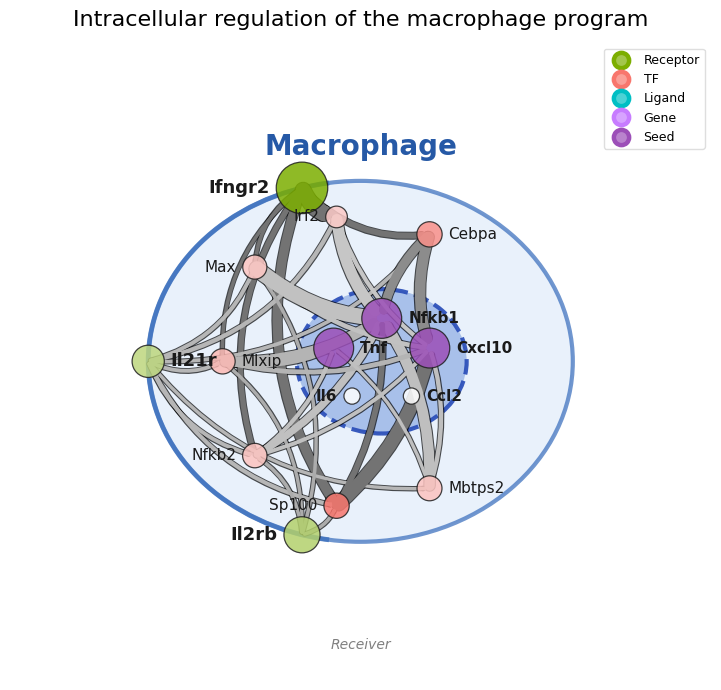

{'upstream_r_tf': 0,
 'upstream_tf_lig': 0,
 'lig_rec': 0,
 'rec_tf': 17,
 'tf_gene': 17}

In [7]:
fig, ax, intracellular_edges = cascade_plot(
    multicell, results,
    flow="upstream",
    start_layer="receptors",
    stop_layer="genes",
    title="Intracellular regulation of the macrophage program",
    return_edges=True,
    **common_plot_kwargs,
)
{k: len(v) for k, v in intracellular_edges.items()}

In [8]:
from collections import Counter

labels = Counter(text.get_text() for text in ax.texts)
{name: count for name, count in labels.items() if count > 1}

{}

### Include extracellular ligands

Starting at ligands adds signals produced by other cell types. This answers: **which extracellular signals may regulate the focal program, and through which macrophage receptors and TFs?**

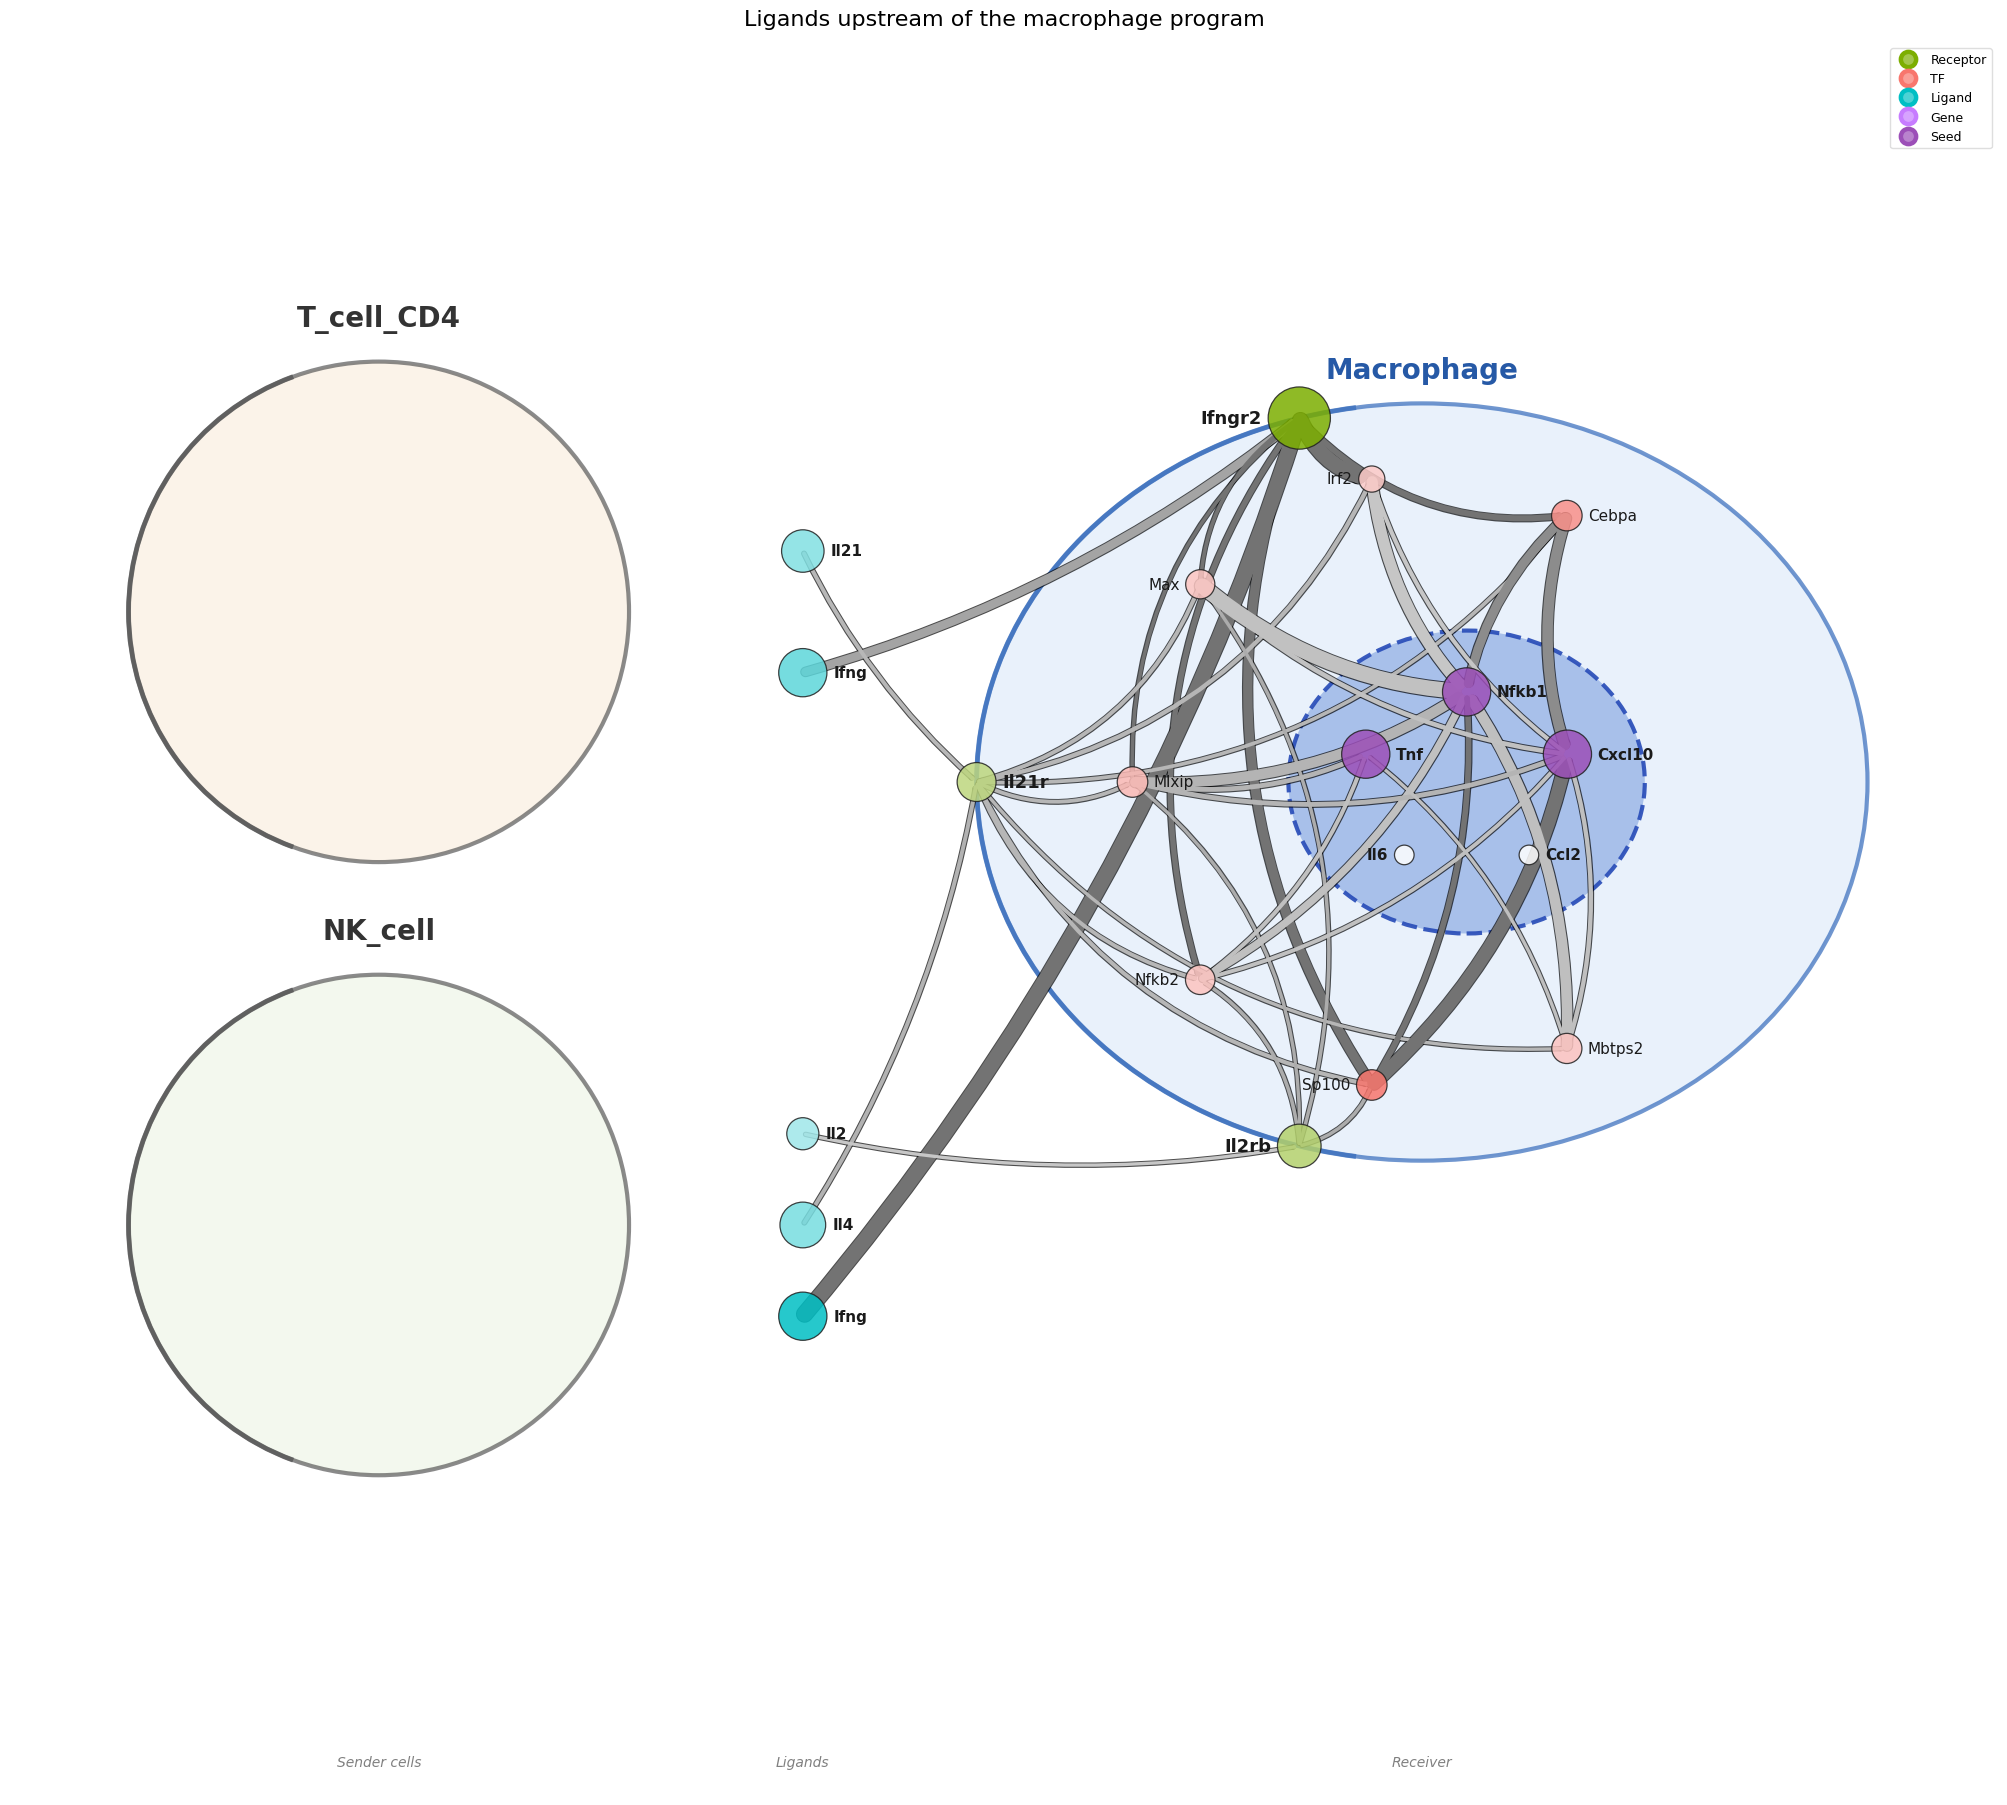

{'upstream_r_tf': 0,
 'upstream_tf_lig': 0,
 'lig_rec': 5,
 'rec_tf': 17,
 'tf_gene': 17}

In [9]:
fig, ax, ligand_edges = cascade_plot(
    multicell, results,
    flow="upstream",
    start_layer="ligands",
    stop_layer="genes",
    title="Ligands upstream of the macrophage program",
    return_edges=True,
    **common_plot_kwargs,
)
{k: len(v) for k, v in ligand_edges.items()}

### Complete source-cell cascade

Leaving the layer window unset displays the complete connected mechanism. It adds receptors and TFs in ligand-producing cells, answering: **which programs in neighboring cells may control production of the upstream ligands?**

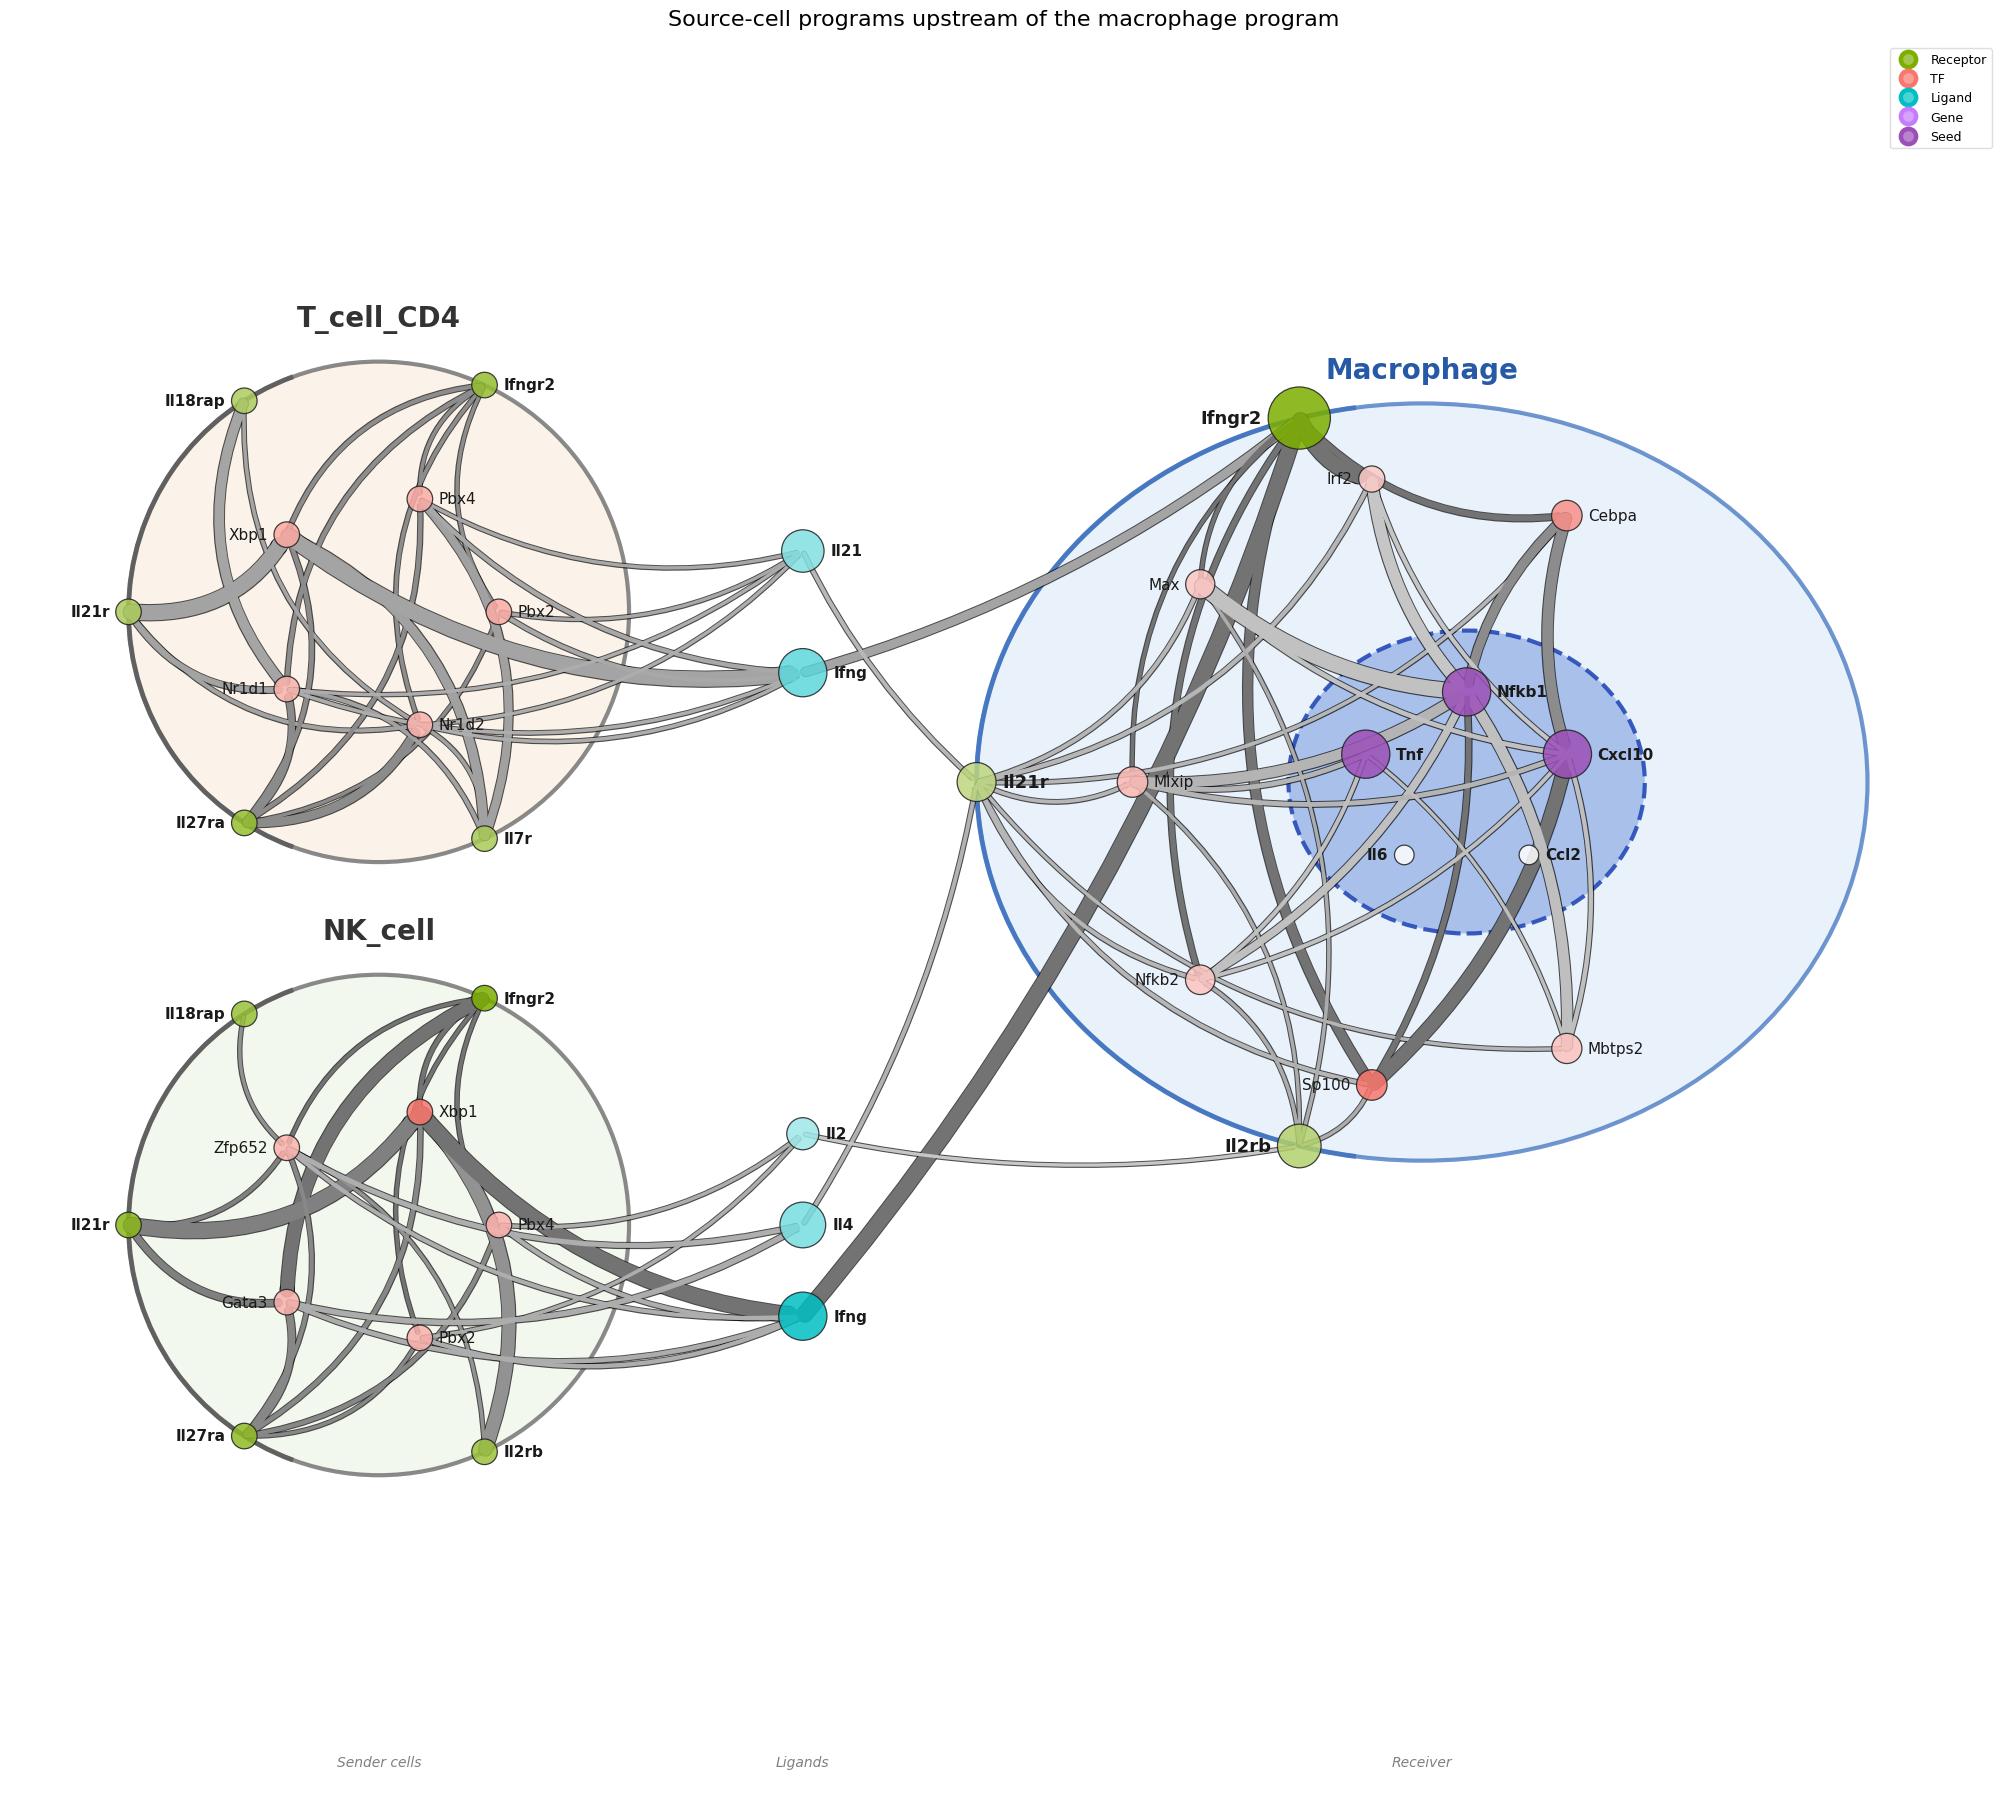

{'upstream_r_tf': 35,
 'upstream_tf_lig': 18,
 'lig_rec': 5,
 'rec_tf': 17,
 'tf_gene': 17}

In [10]:
fig, ax, complete_edges = cascade_plot(
    multicell, results,
    flow="upstream",
    title="Source-cell programs upstream of the macrophage program",
    return_edges=True,
    **common_plot_kwargs,
)
{k: len(v) for k, v in complete_edges.items()}

## 3. Inspect and save the selected cascade

`return_edges=True` exposes the exact edge tables used by the figure. Inspecting them is important when a layer is unexpectedly empty or a cell type disappears: cascade plots retain only complete paths connecting the selected layers.

In [11]:
edge_count_summary = pd.DataFrame({
    "intracellular": {k: len(v) for k, v in intracellular_edges.items()},
    "from_ligands": {k: len(v) for k, v in ligand_edges.items()},
    "complete": {k: len(v) for k, v in complete_edges.items()},
}).T
edge_count_summary

,upstream_r_tf,upstream_tf_lig,lig_rec,rec_tf,tf_gene
intracellular,0,0,0,17,17
from_ligands,0,0,5,17,17
complete,35,18,5,17,17


Saved: macrophage_cascade.png


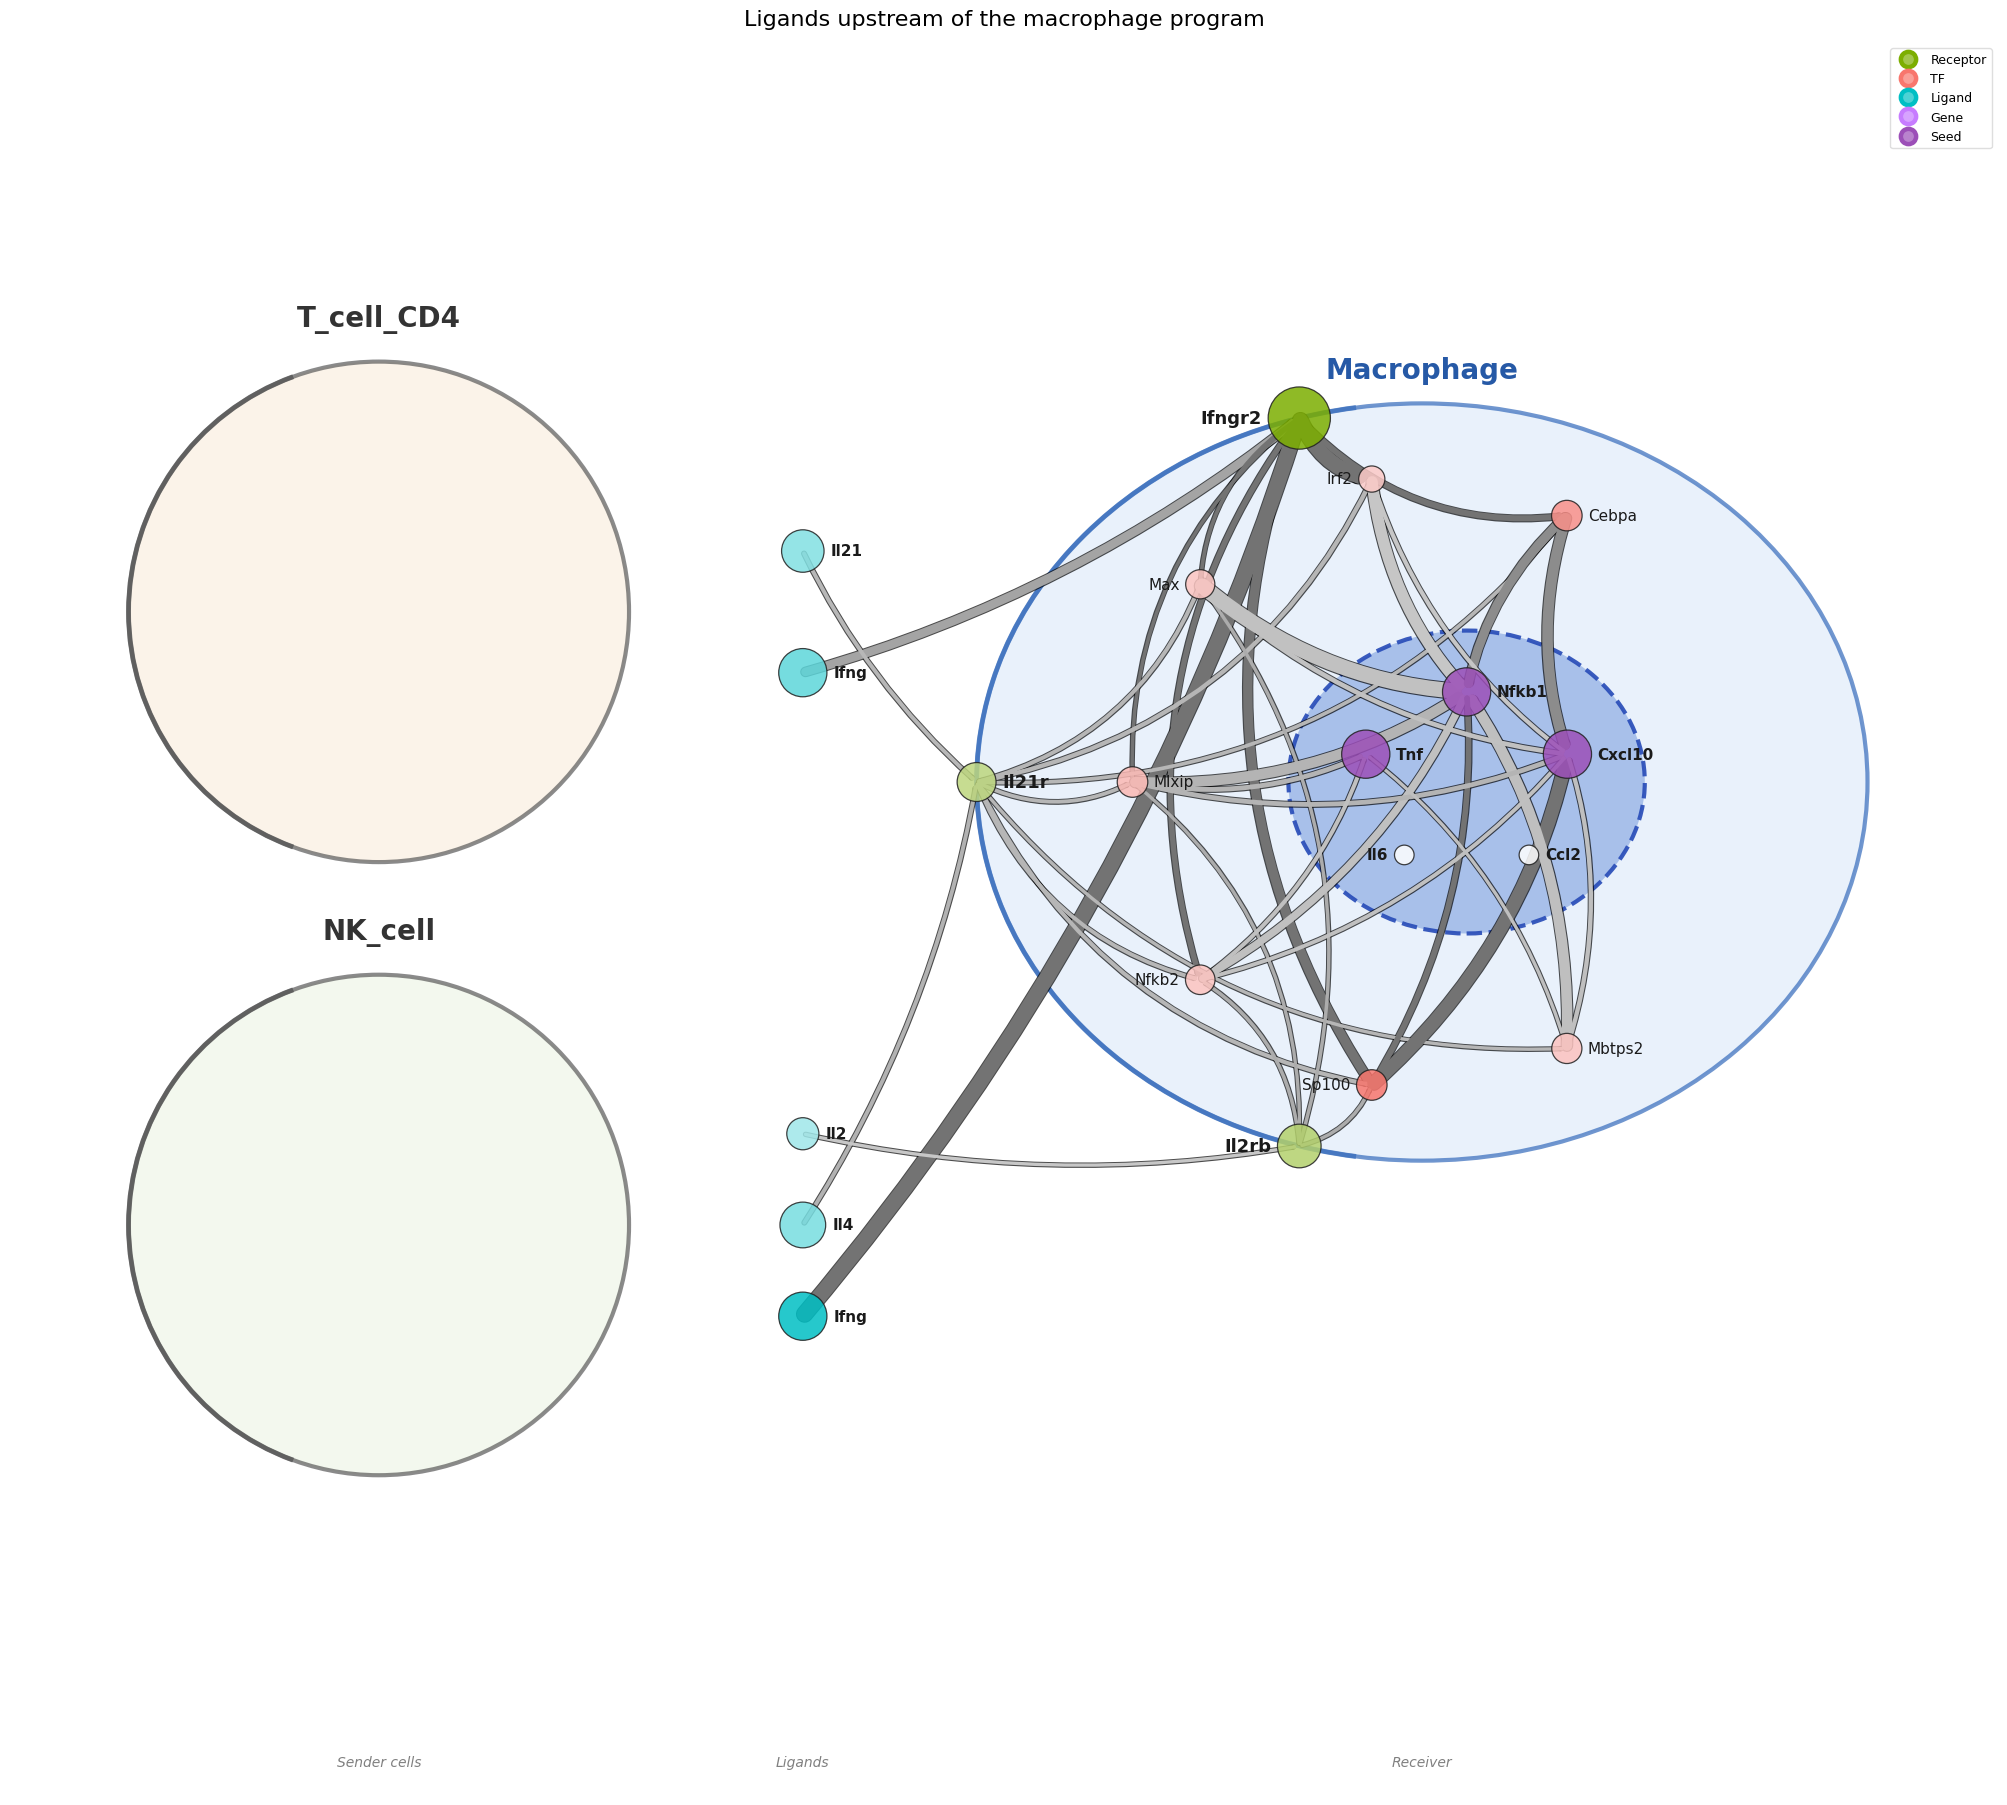

(<Figure size 2516.45x1815.84 with 1 Axes>,
 <Axes: title={'center': 'Ligands upstream of the macrophage program'}>)

In [12]:
cascade_plot(
    multicell, results,
    flow="upstream",
    start_layer="ligands", stop_layer="genes",
    title="Ligands upstream of the macrophage program",
    save_path="macrophage_cascade.png",
    **common_plot_kwargs,
)

## 4. Compare two matched runs

A standard cascade shows which paths support one RWR result, whereas a contrast cascade highlights **where two matched analyses differ**. To mimic two contexts, we keep the same nodes and network layers but perturb two inputs: context B receives a reproducible permutation of the weights of 35% of the cell-communication edges, and the two contexts emphasize complementary halves of the seed program. This is synthetic data for learning the API, not a biological comparison. In a real analysis, use measured context-specific communication networks and seed weights—for example, the healthy and fibrotic niches from tutorial 6.

The two analyses must use compatible node names and network layers so that their scores can be compared along the same paths.

In [ ]:
def build_context_model(context_ccc, context_seeds):
    model = recon.explore.Multicell(
        celltypes={ct: recon.explore.Celltype(
            celltype_name=ct, grn_graph=grn,
            receptor_grn_bipartite=receptor_genes,
            receptor_graph_directed=False, receptor_graph_weighted=False,
            grn_graph_directed=False, grn_graph_weighted=True,
            receptor_grn_bipartite_graph_directed=False,
            receptor_grn_bipartite_graph_weighted=True, seeds=[],
        ) for ct in celltypes},
        cell_communication_graph=context_ccc,
        cell_communication_graph_directed=False,
        cell_communication_graph_weighted=True,
        bipartite_grn_cell_communication_directed=False,
        bipartite_grn_cell_communication_weighted=False,
        bipartite_cell_communication_receptor_directed=False,
        bipartite_cell_communication_receptor_weighted=False,
        seeds=context_seeds,
    )
    model.lamb = recon.explore.set_lambda(
        model, direction="upstream", strategy="intercell"
    )
    return model

context_ccc_a = ccc[
    ccc["celltype_source"].isin(celltypes)
    & ccc["celltype_target"].isin(celltypes)
].copy()
context_ccc_b = context_ccc_a.copy()
perturbed_edges = context_ccc_b.sample(frac=0.35, random_state=7).index
permuted_weights = context_ccc_b.loc[perturbed_edges, "weight"].to_numpy(copy=True)
np.random.default_rng(7).shuffle(permuted_weights)
context_ccc_b.loc[perturbed_edges, "weight"] = permuted_weights

seed_nodes = [f"{gene}::{focal_celltype}" for gene in seed_genes]
split = (len(seed_nodes) + 1) // 2
seeds_a = {node: (1.0 if i < split else 0.2) for i, node in enumerate(seed_nodes)}
seeds_b = {node: (0.2 if i < split else 1.0) for i, node in enumerate(seed_nodes)}

multicell_a = build_context_model(context_ccc_a, seeds_a)
multicell_b = build_context_model(context_ccc_b, seeds_b)
results_a = multicell_a.explore(restart_proba=0.6)
results_b = multicell_b.explore(restart_proba=0.6)

Before plotting, compare the score mass assigned to every multiplex layer in each context. A layer-wide imbalance can explain why most nodes in that layer share one contrast color. `total_abs_weight` is the most useful diagnostic because contrast colors are based on differences between absolute RWR scores.

In [ ]:
layer_score_mass = (
    pd.concat({"context A": results_a, "context B": results_b}, names=["context"])
    .reset_index(level="context")
    .groupby(["context", "multiplex"])["score"]
    .agg(
        total_weight="sum",
        total_abs_weight=lambda values: values.abs().sum(),
        mean_weight="mean",
        n_nodes="size",
    )
)
layer_score_mass

In [ ]:
fig, ax, contrast_edges = contrast_cascade_plot(
    {"context A": multicell_a, "context B": multicell_b},
    results_a, results_b,
    flow="upstream",
    start_layer="ligands",
    stop_layer="genes",
    title="Synthetic context contrast",
    normalize_receiver_scores=False,
    delta_min_quantile=0.0,
    delta_min_color_fraction=0.25,
    return_edges=True,
    **common_plot_kwargs,
)
{k: len(v) for k, v in contrast_edges.items()}

Blue nodes have a higher absolute RWR score in context B, red nodes in context A, and near-white nodes change little. `normalize_receiver_scores=False` preserves these raw score differences. `delta_min_quantile=0.0` keeps all selected paths in this small example; increasing it focuses the figure on the strongest differences.

### Expand the contrast and reveal relative differences

The compact plot can retain only a small number of connected ligands and receptors. The `top_*_n` parameters are **candidate-selection limits**, not visual decoration: increasing them asks ReCoN to search a broader set of highly ranked nodes before retaining complete paths. Here we increase the ligand, receptor, and TF limits to expose a richer contrast. This may increase visual density and runtime.

We also enable `normalize_receiver_scores=True`. ReCoN then rescales score differences separately among receiving-cell receptors, TFs, and genes by the largest absolute difference in each layer. This improves color contrast between layers whose raw differences have very different magnitudes, while preserving every node's direction. Red and blue therefore retain the same run-specific meaning as above, but their color intensity is relative to the strongest change in that receiver layer; use the preceding unnormalized plot when magnitudes must be compared directly across layers.

In [ ]:
expanded_plot_kwargs = {
    **common_plot_kwargs,
    "top_ligand_n": 20,
    "top_receptor_n": 20,
    "top_tf_n": 15,
}

fig, ax, expanded_contrast_edges = contrast_cascade_plot(
    {"context A": multicell_a, "context B": multicell_b},
    results_a, results_b,
    flow="upstream",
    start_layer="ligands",
    stop_layer="genes",
    title="Expanded synthetic context contrast",
    normalize_receiver_scores=True,
    delta_min_quantile=0.0,
    delta_min_color_fraction=0.25,
    return_edges=True,
    **expanded_plot_kwargs,
)
{k: len(v) for k, v in expanded_contrast_edges.items()}

**How to tune the contrast**

- Increase `top_ligand_n`, `top_receptor_n`, or `top_tf_n` when too few candidates from that molecular layer are represented. Because only connected paths survive, requesting 20 candidates does not guarantee 20 displayed nodes.
- Increase `before_top_n` only when displaying the complete source-cell cascade; it controls receptors and TFs upstream of the ligands.
- Increase `delta_min_quantile` to remove edges associated with small score differences and simplify a dense figure. Keep it near zero when exploring whether a path exists.
- Increase `delta_min_color_fraction` to make small non-zero differences easier to see. This affects color visibility, not edge selection or the underlying score.
- Set `normalize_receiver_scores=False` to compare raw difference magnitudes across layers; set it to `True` when each receiver layer should use its own color range.

```{warning}
A cascade is a network-based explanation of the RWR results, not proof that every displayed interaction occurs in the sample. Only connected paths present in the GRN, receptor prior, and CCC network can appear. Validate important mechanisms experimentally and against expression evidence.
```

```{tip}
If a layer is empty, use `verbose=True`, inspect the returned edge tables, or increase `top_ligand_n`, `top_receptor_n`, `top_tf_n`, and `before_top_n`.
```